In [1]:
import pandas as pd
import numpy as np


groups = ["NCD", 'AI', 'AS(NA)', 'BL',
         'NAC', 'AS(NAC)', 'CS', 'AT', 'NA','ADL', 'NAD']

columns = [f"{group}_{t}" for group in groups for t in range(7)]
columns.append("target")

df = pd.read_csv(
    "Twitter.data",
    header=None,
    names=columns
)

print(df.shape)
#df.head(20)

(583250, 78)


In [2]:
df["target_log"] = np.log1p(df["target"])

In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1. Ознаки і target
# -----------------------------
X = df.drop(columns=["target", "target_log"])
y = df["target_log"]

# -----------------------------
# 2. Train / test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 3. Lasso Regression with CV
# -----------------------------
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LassoCV(
        cv=5,
        random_state=42,
        max_iter=10000,
        n_jobs=-1
    ))
])

# навчання
lasso_model.fit(X_train, y_train)

# прогноз
y_pred_log = lasso_model.predict(X_test)

# -----------------------------
# 4. Метрики в log-масштабі
# -----------------------------
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = mean_squared_error(y_test, y_pred_log) ** 0.5
r2_log = r2_score(y_test, y_pred_log)

print("Lasso Regression on log(target)")
print(f"Best alpha: {lasso_model.named_steps['regressor'].alpha_:.6f}")
print(f"MAE  (log scale): {mae_log:.4f}")
print(f"RMSE (log scale): {rmse_log:.4f}")
print(f"R²   (log scale): {r2_log:.4f}")

Lasso Regression on log(target)
Best alpha: 0.001157
MAE  (log scale): 1.0419
RMSE (log scale): 1.4052
R²   (log scale): 0.5109


In [4]:
coefs = lasso_model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coefs,
    "abs_coefficient": np.abs(coefs)
})

coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("Кількість ненульових коефіцієнтів:", (coef_df["coefficient"] != 0).sum())
coef_df.head(20)

Кількість ненульових коефіцієнтів: 55


,feature,coefficient,abs_coefficient
29,NAC_1,0.528809,0.528809
1,NCD_1,-0.497230,0.497230
5,NCD_5,-0.433785,0.433785
33,NAC_5,0.340865,0.340865
19,AS(NA)_5,0.283253,0.283253
60,NA_4,-0.240511,0.240511
7,AI_0,0.230645,0.230645
59,NA_3,-0.229093,0.229093
11,AI_4,0.202160,0.202160
20,AS(NA)_6,0.200631,0.200631


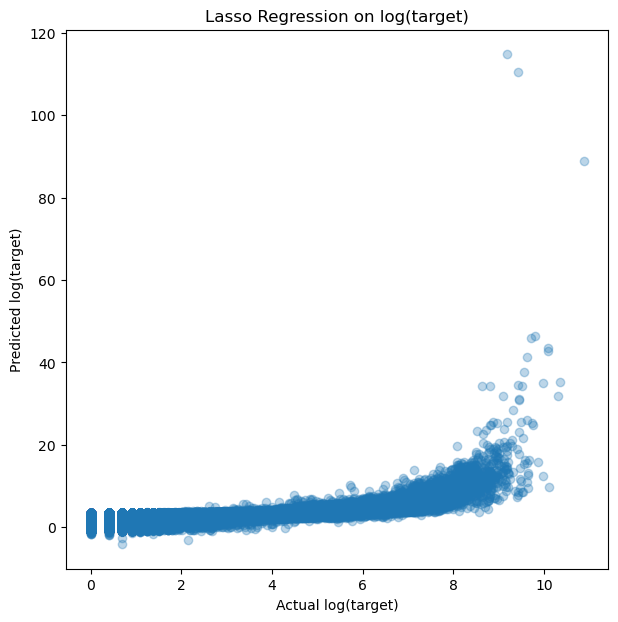

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_log, alpha=0.3)
plt.xlabel("Actual log(target)")
plt.ylabel("Predicted log(target)")
plt.title("Lasso Regression on log(target)")
plt.show()